In [60]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

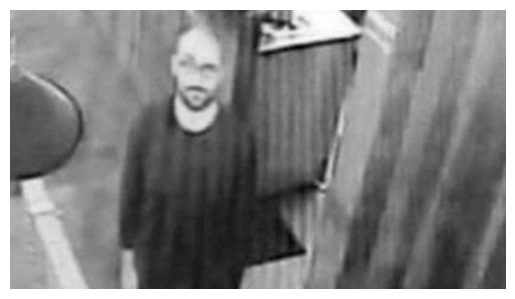

In [61]:
gambar1 = cv2.imread("backup.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(gambar1, cmap="gray")
plt.axis("off")
plt.show()

In [62]:
def filter_citra(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total_sum = 0
                    for row in region:
                        for pixel in row:
                            total_sum += int(pixel)
                    
                    canvas[i, j] = total_sum // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = []
                    for row in region:
                        for val in row:
                            values.append(val)
                    # urutkan manual / manual sort (bubble sort)
                    n = len(values)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if values[b] > values[b + 1]:
                                values[b], values[b + 1] = values[b + 1], values[b]
                    # ambil nilai tengah / get middle value
                    mid = n // 2
                    if n % 2 == 0:
                        canvas[i, j] = (values[mid - 1] + values[mid]) // 2
                    else:
                        canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val
    # kembalikan gambar / return image
    return canvas

# cara panggil / how to call
# hasil = filter_citra(foto_karim, 3, 'mean')

In [63]:
def convolution(img, kernel):
    # Ukuran kernel
    size = kernel.shape[0]
    
    # Ukuran padding
    pad_size = size // 2
    
    # Tambah padding nol (constant)
    padded = np.pad(img, pad_size, mode='constant')
    
    # Kanvas hasil (gunakan float32 untuk menampung nilai negatif/desimal)
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            # Area kernel
            region = padded[i:i+size, j:j+size]
            # Hitung konvolusi: jumlah dari perkalian region dengan kernel
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

In [64]:
# --- Kernel Perbaikan Citra ---
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

# --- Kernel Sobel ---
sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

# --- Kernel Prewitt ---
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# --- Kernel Roberts ---
robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

In [65]:
def edge_detection(img, kernelx, kernely):
    # Konvolusi sumbu x dan y
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    # Gabung gradien absolut agar tidak ada nilai negatif
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke rentang 0-255
    if np.max(canvas) != 0:
        canvas = (canvas * 255.0) / np.max(canvas)
    
    # Batas nilai (clip) dan konversi ke uint8
    return np.clip(canvas, 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

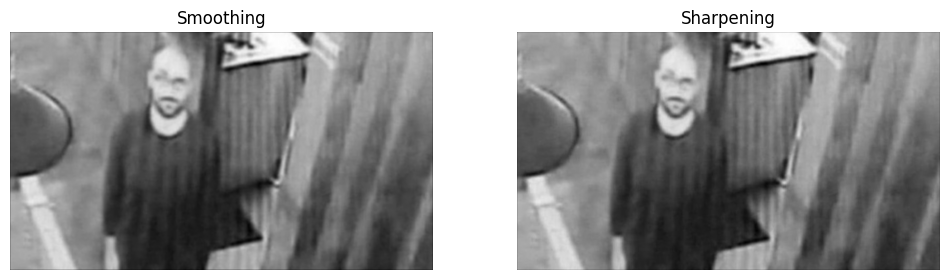

In [66]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
konvosmooth = convolution(gambar1, kernelSmoothing)
plt.imshow(konvosmooth, cmap="gray")
plt.title("Smoothing")
plt.axis("off")

plt.subplot(1, 2, 2)
konvosharp = convolution(gambar1, kernelSharpening)
plt.imshow(konvosharp, cmap="gray")
plt.title("Sharpening")
plt.axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

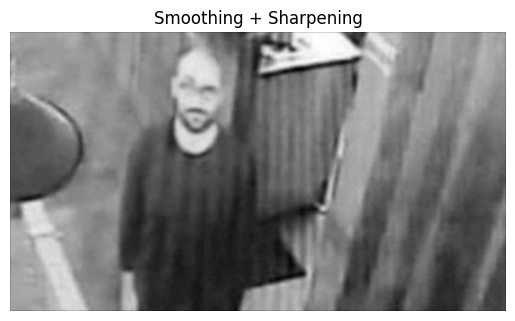

In [67]:
gabungan = konvosmooth + konvosharp
plt.imshow(gabungan, cmap="gray")
plt.title("Smoothing + Sharpening")
plt.axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

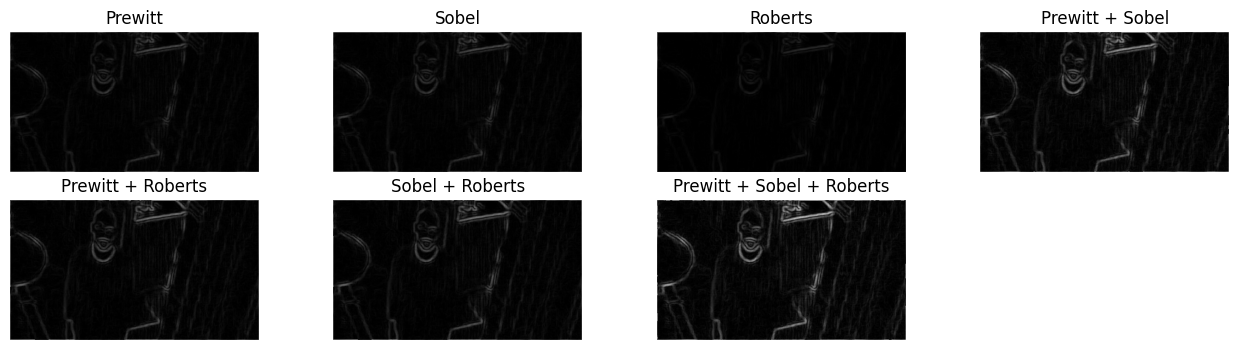

In [68]:
plt.figure(figsize=(16, 4))
plt.subplot(2, 4, 1)
prewitt = edge_detection(gabungan, prewittx, prewitty)
plt.imshow(prewitt, cmap="gray")
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2, 4, 2)
sobel = edge_detection(gabungan, sobelx, sobely)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(2, 4, 3)
roberts = edge_detection(gabungan, robertsx, robertsy)
plt.imshow(roberts, cmap="gray")
plt.title("Roberts")
plt.axis("off")

ps = prewitt + sobel
pr = prewitt + roberts
sr = sobel + roberts
psr = prewitt + sobel + roberts

plt.subplot(2, 4, 4)
plt.imshow(ps, cmap="gray")
plt.title("Prewitt + Sobel")   
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(pr, cmap="gray")
plt.title("Prewitt + Roberts")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(sr, cmap="gray")
plt.title("Sobel + Roberts")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(psr, cmap="gray")
plt.title("Prewitt + Sobel + Roberts")
plt.axis("off")

In [69]:
def thresholding(image, angka):
    h, w = image.shape
    hasil = np.zeros((h,w), dtype=image.dtype)
    
    for x in range(h):
        for y in range(w):
            if(image[x,y] >= angka):
                hasil[x,y] = 255
            else:
                hasil[x,y] = 0
    return hasil

sepuluh = thresholding(pr, 10)
duaPuluh = thresholding(pr, 20)
tigaPuluh = thresholding(pr, 30)
empatPuluh = thresholding(pr, 40)
limaPuluh = thresholding(pr, 50)
enamPuluh = thresholding(pr, 60)

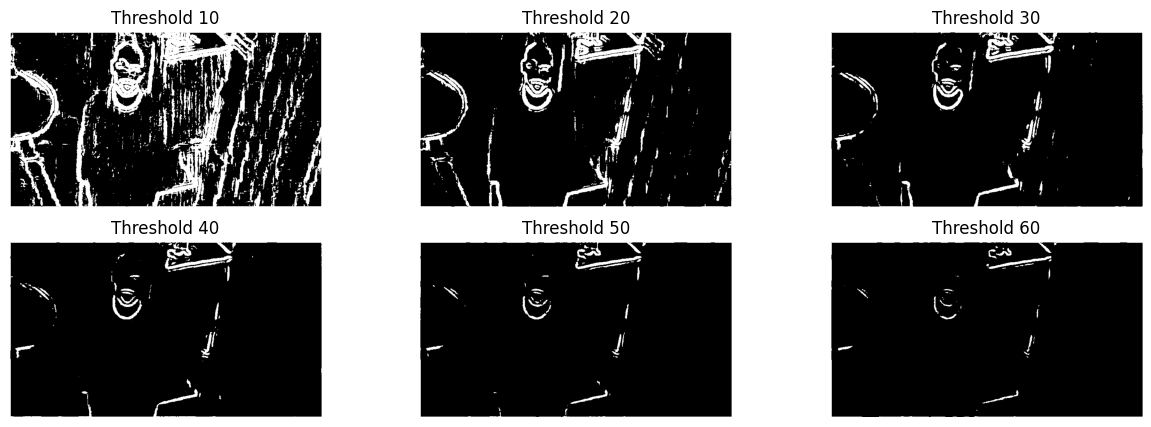

In [70]:
plt.figure(figsize=(15, 5))
plt.subplot(2, 3, 1)
plt.imshow(sepuluh, cmap='gray')
plt.title("Threshold 10")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(duaPuluh, cmap='gray')
plt.title("Threshold 20")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(tigaPuluh, cmap='gray')
plt.title("Threshold 30")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(empatPuluh, cmap='gray')
plt.title("Threshold 40")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(limaPuluh, cmap='gray')
plt.title("Threshold 50")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(enamPuluh, cmap='gray')
plt.title("Threshold 60")
plt.axis("off")
plt.show()


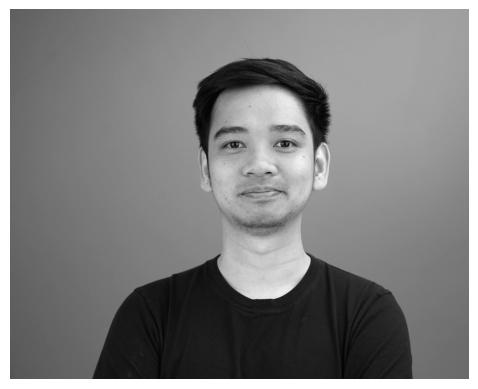

In [71]:
gambar2 = cv2.imread("david.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(gambar2, cmap="gray")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

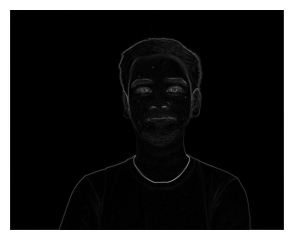

In [87]:
deteksi = edge_detection(gambar2, prewittx, prewitty)

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(deteksi, cmap='gray')
plt.axis("off")


In [ ]:
plt.subplot(2, 4, 1)
mean3 = filter_citra(gambar1, 3, "mean")
plt.imshow(mean3, cmap="gray")
plt.title("Mean Filter 3x3")

(np.float64(-0.5), np.float64(977.5), np.float64(787.5), np.float64(-0.5))

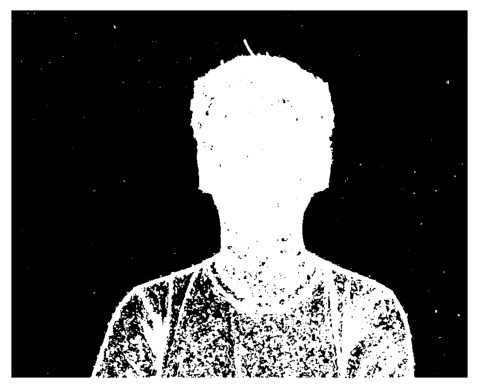

In [86]:
baru = filter_citra(deteksi, 3, "mean")
convoUltraInstinct = convolution(baru, kernelSharpening)
ultraInstinct = thresholding(convoUltraInstinct, 2.5)
plt.imshow(ultraInstinct, cmap="gray")
plt.axis("off")

In [96]:
MedianUltraInstinct = filter_citra(ultraInstinct,  9, "median")
plt.imshow(MedianUltraInstinct, cmap="gray")
print(MedianUltraInstinct.shape)

KeyboardInterrupt: 

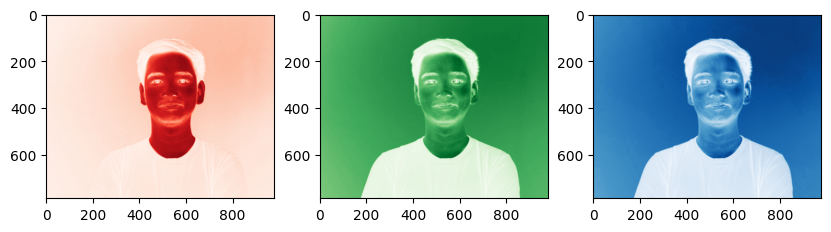

In [90]:
dav = plt.imread('david.jpg')
red = dav[:, :, 0]
green = dav[:, :, 1]
blue = dav[:, :, 2]

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(red, cmap="Reds")
plt.subplot(1, 3, 2)
plt.imshow(green, cmap="Greens")
plt.subplot(1, 3, 3)
plt.imshow(blue, cmap="Blues")

In [91]:
def mask_method(img, mask):
    imgCopy = img.copy()
    mask_zero = mask == 0
    imgCopy[mask_zero] = 255
    return imgCopy

In [ ]:
ultraInstinctRed = mask_method(red, MedianUltraInstinct) 
ultraInstinctGreen = mask_method(green, MedianUltraInstinct) 
ultraInstinctBlue = mask_method(blue, MedianUltraInstinct) 

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(ultraInstinctRed, cmap="Reds")
plt.subplot(1, 3, 2)
plt.imshow(ultraInstinctGreen, cmap="Greens")
plt.subplot(1, 3, 3)
plt.imshow(ultraInstinctBlue, cmap="Blues")

NameError: name 'UltraInstinct' is not defined

In [ ]:
Final = np.zeros_like(dav)
Final[:, :, 0] = ultraInstinctRed
Final[:, :, 1] = ultraInstinctGreen
Final[:, :, 2] = ultraInstinctBlue
plt.figure(figsize=(8, 8))
plt.imshow(Final)

NameError: name 'ultraInstinctRedBoboiboy' is not defined